# Prediction of Product Sales

- Author: Salam Odeh

## Load and Inspect Data

In [14]:
# Mount Google Drive (Colab specific - skip if running locally)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

In [16]:
# Load the sales prediction dataset
# Adjust this path to wherever you saved the CSV in your Drive
fpath =  '/content/drive/MyDrive/Colab Notebooks/0.0 - project/Sales Prediction/sales_predictions_2023.csv'

df = pd.read_csv(fpath)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Clean Data

**Important note for this assignment:** in Part 2 we filled missing values with
placeholders (`0` for `Item_Weight`, `'MISSING'` for `Outlet_Size`) so our EDA
functions could *report* on the presence of nulls. For Part 4, the instructions
ask us to **remove those placeholders and replace them with actual null values
(`np.nan`)** so that our `explore_*` functions correctly detect and report null
counts/percentages as part of this feature inspection.

In [17]:
# Drop duplicates (none found previously, but good practice)
df = df.drop_duplicates()

# Fix inconsistent categories in Item_Fat_Content (same as Part 2)
fat_content_map = {
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
}
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_content_map)

# --- REMOVE WEEK 2 PLACEHOLDERS, REPLACE WITH ACTUAL NULL VALUES ---

# Item_Weight: the placeholder 0 is not a realistic product weight,
# so replace 0 with np.nan
df['Item_Weight'] = df['Item_Weight'].replace(0, np.nan)

# Outlet_Size: replace the 'MISSING' placeholder string with np.nan
df['Outlet_Size'] = df['Outlet_Size'].replace('MISSING', np.nan)

# Confirm null counts are now restored
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## EDA Functions

These custom functions will be used to inspect each feature (univariate) and each feature vs. the target (multivariate).

In [18]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""

def explore_categorical(df, x, fillna=True, placeholder='MISSING',
                         figsize=(6, 4), order=None):
    """Creates a seaborn countplot with the option to temporarily fill missing values.
    Prints statements about null values, cardinality, and checks for
    constant/quasi-constant features.
    """
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # Before filling nulls, save null value counts and percent for printing
    null_count = temp_df[x].isna().sum()
    null_perc = null_count / len(temp_df) * 100
    # fillna with placeholder
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # Create figure with desired figsize
    fig, ax = plt.subplots(figsize=figsize)
    # Plotting a count plot
    sns.countplot(data=temp_df, x=x, ax=ax, order=order)
    # Rotate tick labels for long names
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # Add a title with the feature name included
    ax.set_title(f"Column: {x}", fontweight='bold')

    # Fix layout and show plot (before print statements)
    fig.tight_layout()
    plt.show()

    # Print null value info
    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    # Print cardinality info
    nunique = temp_df[x].nunique()
    print(f"- Unique Values: {nunique}")
    # Find value counts of feature
    val_counts = temp_df[x].value_counts(dropna=False)
    # Define the most common value
    most_common_val = val_counts.index[0]
    # Define the frequency of the most common value
    freq = val_counts.values[0]
    # Calculate the percentage of the most common value
    perc_most_common = freq / len(temp_df) * 100
    # Print the results
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")
    # Print message if quasi-constant or constant (most common val more than 98% of data)
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
        print("- Not constant or quasi-constant.")
    return fig, ax


def explore_numeric(df, x, figsize=(6, 5)):
    """Creates a seaborn histplot and boxplot with a shared x-axis.
    Prints statements about null values, cardinality, and checks for
    constant/quasi-constant features.
    """
    # Save null value counts and percent for printing
    null_count = df[x].isna().sum()
    null_perc = null_count / len(df) * 100

    # Making our figure with gridspec for subplots
    gridspec = {'height_ratios': [0.7, 0.3]}
    fig, axes = plt.subplots(nrows=2, figsize=figsize,
                              sharex=True, gridspec_kw=gridspec)
    # Histogram on top
    sns.histplot(data=df, x=x, ax=axes[0])

    # Boxplot on bottom
    sns.boxplot(data=df, x=x, ax=axes[1])

    # Adding a title
    axes[0].set_title(f"Column: {x}", fontweight='bold')

    # Adjusting subplots to best fill figure
    fig.tight_layout()

    # Ensure plot is shown before message
    plt.show()

    # Print null value info
    print(f"- NaN's Found: {null_count} ({round(null_perc, 2)}%)")
    # Print cardinality info
    nunique = df[x].nunique()
    print(f"- Unique Values: {nunique}")

    # Get the most common value, its count, and percentage
    most_common_val_count = df[x].value_counts(dropna=False).head(1)
    most_common_val = most_common_val_count.index[0]
    freq = most_common_val_count.values[0]
    perc_most_common = freq / len(df) * 100

    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common, 2)}%)")

    # Print message if quasi-constant or constant (most common val more than 98% of data)
    if perc_most_common > 98:
        print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
        print("- Not constant or quasi-constant.")
    return fig, axes

In [19]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6, 4),
                                fillna=True, placeholder='MISSING',
                                order=None):
    """Plots a combination of a seaborn barplot of means combined with
    a seaborn stripplot to show the spread of the data.
    """
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # fillna with placeholder
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # or drop nulls to prevent unwanted 'nan' group in stripplot
    else:
        temp_df = temp_df.dropna(subset=[x])

    # Create the figure and subplots
    fig, ax = plt.subplots(figsize=figsize)

    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None)

    # Stripplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                   order=order, hue_order=order, legend=False,
                   edgecolor='white', linewidth=0.5,
                   size=3, zorder=0)
    # Rotate xlabels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Add a title
    ax.set_title(f"{x} vs. {y}", fontweight='bold')
    fig.tight_layout()
    return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6, 4)):
    """Plots a seaborn regplot with Pearson's correlation (r) added
    to the title.
    """
    # Calculate the correlation (drop rows with nulls in either column)
    corr = df[[x, y]].corr().round(2)
    r = corr.loc[x, y]

    # Plot the data
    fig, ax = plt.subplots(figsize=figsize)
    scatter_kws = {'ec': 'white', 'lw': 1, 'alpha': 0.5}
    sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

    # Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

    # Make sure the plot is shown before the print statement
    plt.show()

    return fig, ax

## Feature Inspection

For each feature, we will:
1. Add a markdown header with the feature name
2. Paste the feature's definition from the data dictionary
3. Create a univariate visualization showing the distribution of values/categories
4. Answer the feature-inspection questions
5. Create a multivariate visualization plotting the feature vs. the target (`Item_Outlet_Sales`)
6. Answer the feature-vs-target questions

**Target column:** `Item_Outlet_Sales`

### Item_Identifier

- Item_Identifier: Unique product ID

In [20]:
# Confirming the dtype to select correct EDA function
feature = "Item_Identifier"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


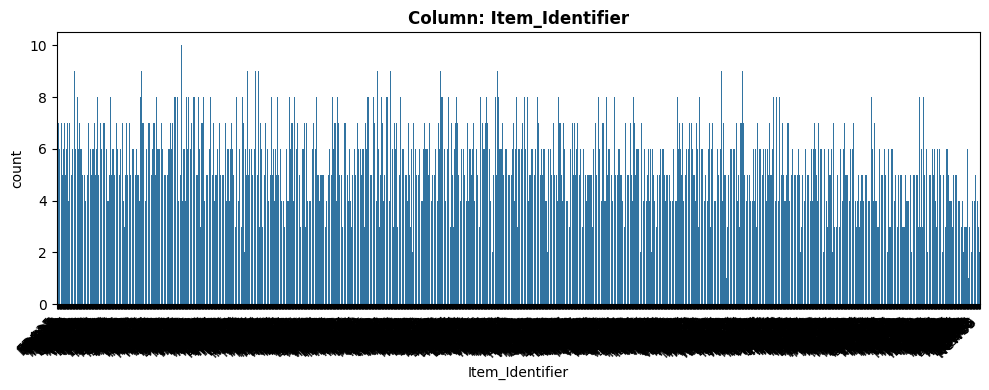

- NaN's Found: 0 (0.0%)
- Unique Values: 1559
- Most common value: 'FDW13' occurs 10 times (0.12%)
- Not constant or quasi-constant.


In [21]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature, figsize=(10, 4));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Categorical (nominal) - it is a unique product code/ID.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No, it is the opposite extreme - extremely high cardinality (no single value dominates).

4. What is the cardinality? Is it high (>10)?
   - 1,559 unique values. Cardinality is extremely high.

5. Would we know this feature before the target is determined?
   - Yes, the product ID is known before a sale occurs.

6. Is there a business case/understanding reason to exclude based on our business case?
   - Yes. This is a unique identifier with no inherent predictive meaning (it's essentially a random label per product). With cardinality this high, one-hot encoding it would create 1,559 new columns and likely cause severe overfitting. **We will drop this column in Part 5**, as instructed.

In [22]:
# Run the appropriate feature vs. target function (based on dtype)
# (Skipped here due to extremely high cardinality - 1,559 categories would
#  produce an unreadable plot. This further supports dropping this column.)
print(f"Item_Identifier has {df['Item_Identifier'].nunique()} unique values - "
      "skipping feature-vs-target plot due to extreme cardinality.")

Item_Identifier has 1559 unique values - skipping feature-vs-target plot due to extreme cardinality.


- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No. A product's arbitrary ID code should have no causal relationship with how much it sells.
  - Does this feature appear to be a predictor of the target?
    - We cannot meaningfully assess this visually due to its extremely high cardinality. As discussed above, this column will be dropped before modeling.

### Item_Weight

- Item_Weight: Weight of product

In [23]:
# Confirming the dtype to select correct EDA function
feature = "Item_Weight"
df[feature].dtype

dtype('float64')

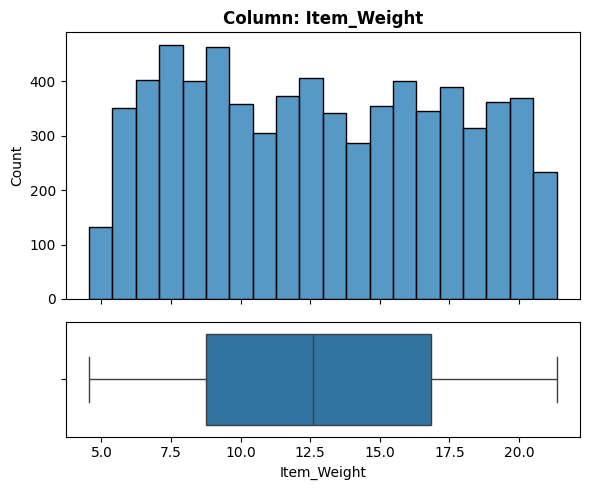

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [24]:
# Run the appropriate explore function (based on feature's dtype)
explore_numeric(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Numeric (continuous).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 1,463 nulls (~17.17%). This is too large a percentage to drop the rows, and the column itself is potentially useful, so we will **impute** the missing values using the **median** with `SimpleImputer` in Part 5 (after the train/test split).

3. Is the feature constant or quasi-constant?
   - No, it has a wide, fairly even spread of values.

4. What is the cardinality? Is it high (>10)?
   - High cardinality (many distinct float values), but that is expected and fine for a continuous numeric feature.

5. Would we know this feature before the target is determined?
   - Yes, a product's weight is a fixed physical attribute known before it is sold.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. Product weight is a reasonable feature to keep - heavier/bulkier items may sell differently than lighter ones.

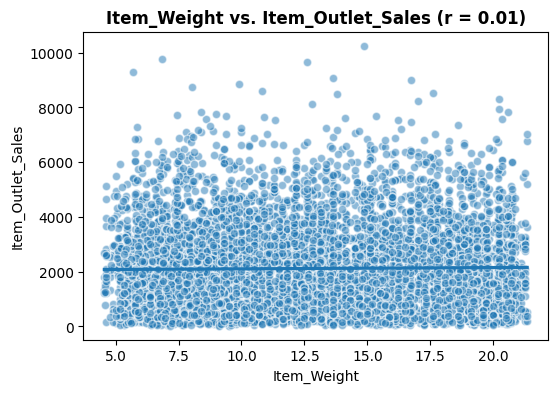

In [25]:
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6, 4)):
    """Plots a seaborn regplot with Pearson's correlation (r) added
    to the title.
    """
    # Calculate the correlation (drop rows with nulls in either column)
    corr = df[[x, y]].corr().round(2)
    r = corr.loc[x, y]

    # Plot the data
    fig, ax = plt.subplots(figsize=figsize)
    # Changed 'lw' to 'linewidths' to avoid the alias conflict
    scatter_kws = {'ec': 'white', 'linewidths': 1, 'alpha': 0.5}
    sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

    # Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

    # Make sure the plot is shown before the print statement
    plt.show()

    return fig, ax

# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Possibly, but likely only a weak one - weight alone probably doesn't drive purchasing decisions as much as price or product category.
  - Does this feature appear to be a predictor of the target?
    - The regplot shows a correlation close to 0, indicating `Item_Weight` has little to no linear relationship with `Item_Outlet_Sales`.

### Item_Fat_Content

- Item_Fat_Content: Whether the product is low fat or regular

In [26]:
# Confirming the dtype to select correct EDA function
feature = "Item_Fat_Content"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


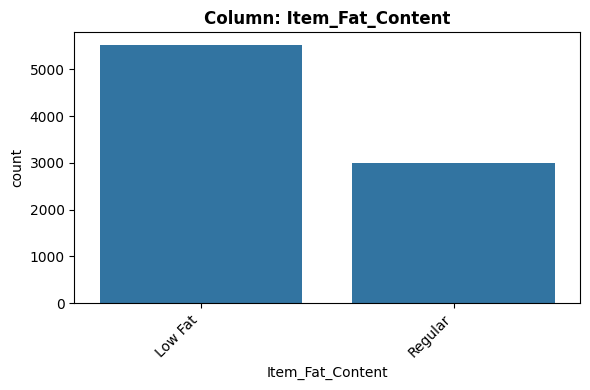

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [27]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Categorical (nominal). (After our Part 2 cleaning, only `'Low Fat'` and `'Regular'` remain.)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - `Low Fat` is the most common value but at roughly 65% of rows, well below the 98% quasi-constant threshold.

4. What is the cardinality? Is it high (>10)?
   - 2 unique values. Cardinality is low.

5. Would we know this feature before the target is determined?
   - Yes, this is a fixed product attribute known before any sale.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. It's a simple, low-cardinality feature that's reasonable to keep.

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


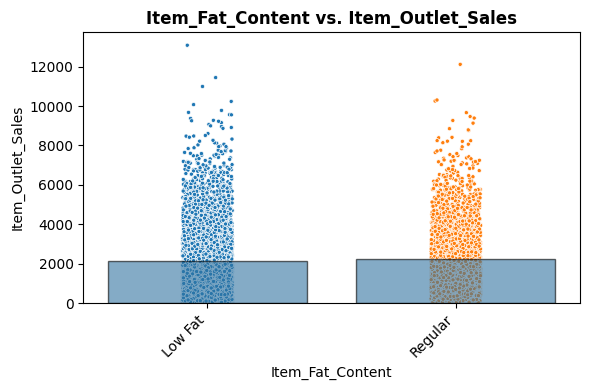

In [28]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Possibly a weak one - some shoppers may prefer low-fat products, but this is unlikely to drive large differences in sales.
  - Does this feature appear to be a predictor of the target?
    - The bar plot shows very similar average `Item_Outlet_Sales` for both `Low Fat` and `Regular`, with heavily overlapping spreads in the stripplot - this feature does not appear to be a strong predictor on its own.

### Item_Visibility

- Item_Visibility: The percentage of total display area of all products in a store allocated to the particular product

In [29]:
# Confirming the dtype to select correct EDA function
feature = "Item_Visibility"
df[feature].dtype

dtype('float64')

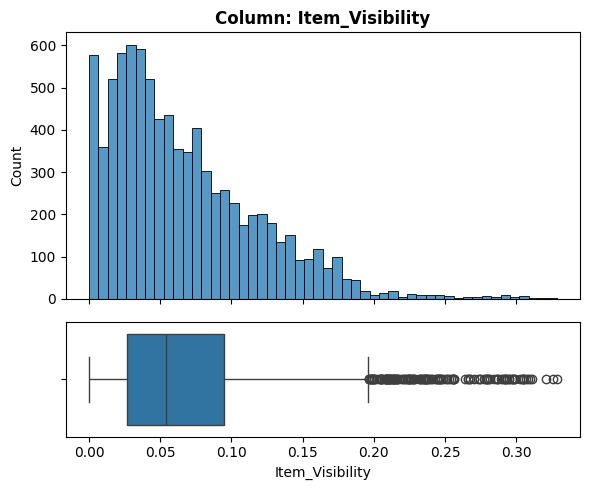

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [30]:
# Run the appropriate explore function (based on feature's dtype)
explore_numeric(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Numeric (continuous).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No, it has a wide right-skewed spread of values (many products at/near 0, with a long tail up to ~0.33).

4. What is the cardinality? Is it high (>10)?
   - High cardinality (continuous float values), which is expected.

5. Would we know this feature before the target is determined?
   - Yes - the display visibility of a product is set by the store and known before sales are recorded.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. This is potentially a useful feature - how prominently a product is displayed could plausibly affect how much it sells.

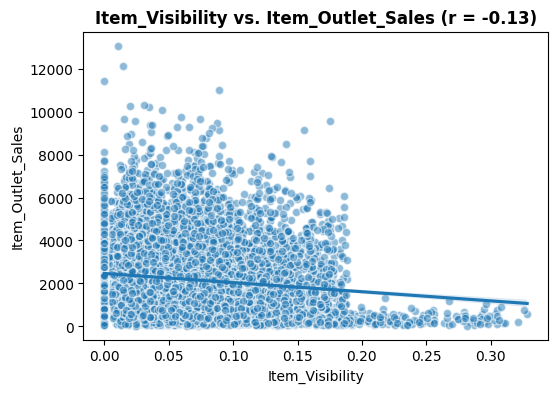

In [31]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, intuitively more visible products might sell more (or conversely, very low-selling items might be displayed more prominently to boost sales).
  - Does this feature appear to be a predictor of the target?
    - The regplot shows a very weak, slightly negative correlation - `Item_Visibility` does not appear to be a strong linear predictor of `Item_Outlet_Sales` on its own.

### Item_Type

- Item_Type: The category to which the product belongs

In [32]:
# Confirming the dtype to select correct EDA function
feature = "Item_Type"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


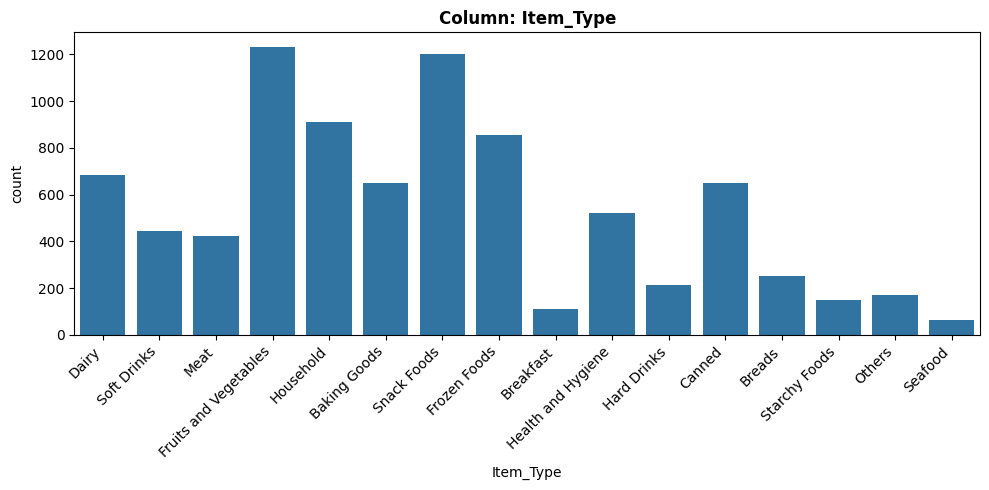

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [33]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature, figsize=(10, 5));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Categorical (nominal).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - the most common category (`Fruits and Vegetables`) makes up only ~14% of rows.

4. What is the cardinality? Is it high (>10)?
   - 16 unique values. Cardinality is moderately high (>10), but still manageable for one-hot encoding.

5. Would we know this feature before the target is determined?
   - Yes, the product category is a fixed attribute known before any sale.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. Product category is likely meaningful for predicting sales (e.g., perishable food categories may have different sales patterns than household goods).

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


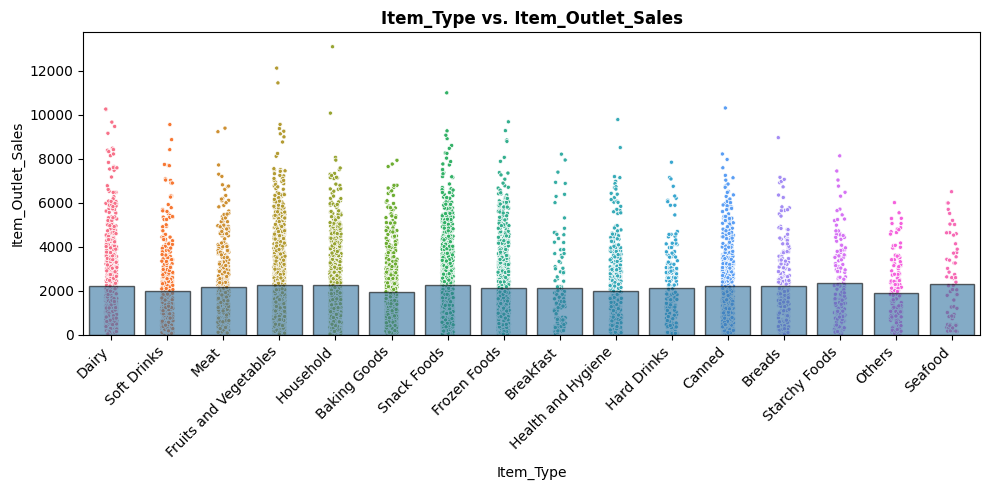

In [34]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales', figsize=(10, 5));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - different product categories (e.g., `Seafood` vs. `Household`) likely have different typical price points and sales volumes.
  - Does this feature appear to be a predictor of the target?
    - The bar plot shows the average `Item_Outlet_Sales` is fairly similar across most categories, with overlapping spreads in the stripplot. There may be a weak effect, but it does not appear to be a dominant predictor on its own.

### Item_MRP

- Item_MRP: Maximum Retail Price (list price) of the product

In [35]:
# Confirming the dtype to select correct EDA function
feature = "Item_MRP"
df[feature].dtype

dtype('float64')

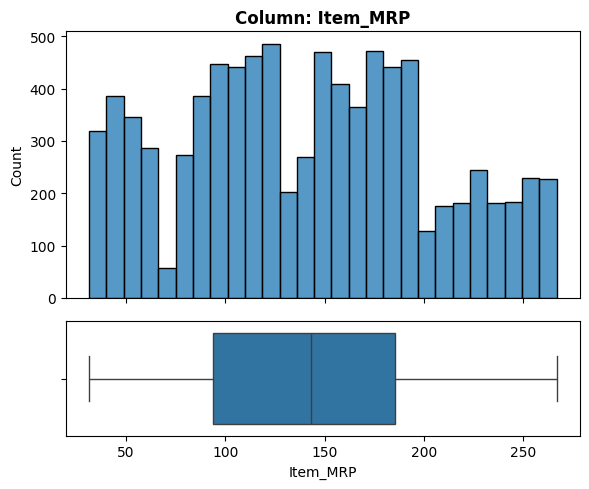

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [36]:
# Run the appropriate explore function (based on feature's dtype)
explore_numeric(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Numeric (continuous).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No, it has a wide spread of values across the price range.

4. What is the cardinality? Is it high (>10)?
   - High cardinality (continuous float values), which is expected and not a concern for numeric features.

5. Would we know this feature before the target is determined?
   - Yes, the list price is set before any sale occurs.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. Price is one of the most intuitive and important drivers of revenue - this should definitely be kept.

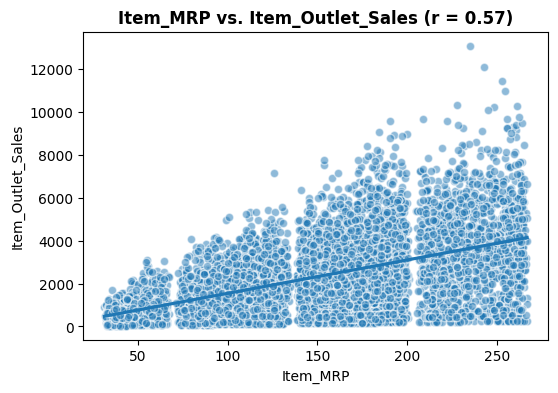

In [37]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - higher-priced items should generally generate higher sales revenue per unit sold.
  - Does this feature appear to be a predictor of the target?
    - Yes. The regplot shows a positive correlation (r ~ 0.57), the strongest of any numeric feature so far. `Item_MRP` appears to be the most important numeric predictor of `Item_Outlet_Sales`.

### Outlet_Identifier

- Outlet_Identifier: Unique store ID

In [38]:
# Confirming the dtype to select correct EDA function
feature = "Outlet_Identifier"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


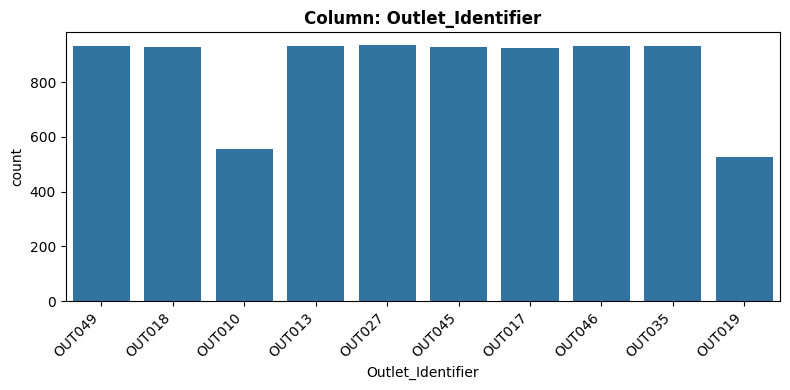

- NaN's Found: 0 (0.0%)
- Unique Values: 10
- Most common value: 'OUT027' occurs 935 times (10.97%)
- Not constant or quasi-constant.


In [39]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature, figsize=(8, 4));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Categorical (nominal).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - the most common outlet (`OUT027`) makes up roughly 11% of rows; values are fairly evenly distributed across 10 outlets.

4. What is the cardinality? Is it high (>10)?
   - 10 unique values. Cardinality is moderate (right at the >10 threshold, but manageable).

5. Would we know this feature before the target is determined?
   - Yes, the specific store is known before any sale.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No, although this overlaps somewhat in information with `Outlet_Size`, `Outlet_Location_Type`, and `Outlet_Type` (each `Outlet_Identifier` corresponds to one combination of those attributes). We will keep it for now, as one-hot encoding 10 categories is manageable.

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


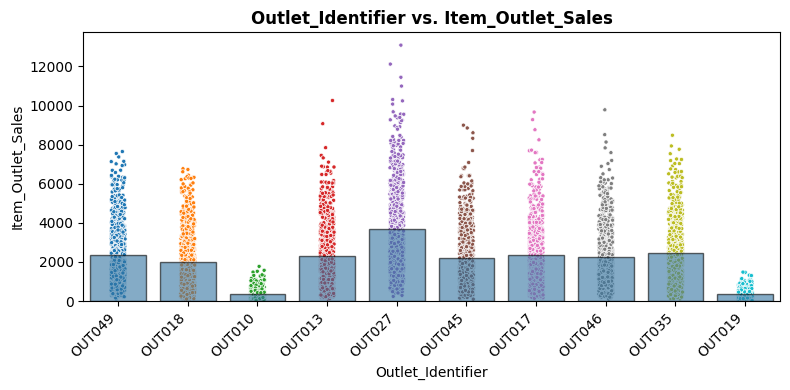

In [40]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales', figsize=(8, 4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - different stores (different sizes, locations, and types) likely have different typical sales levels.
  - Does this feature appear to be a predictor of the target?
    - Yes. The bar plot shows clear differences in average `Item_Outlet_Sales` across outlets - notably `OUT010` and `OUT019` (Grocery Stores) have much lower average sales than the supermarket outlets. `Outlet_Identifier` appears to be a meaningful predictor.

### Outlet_Establishment_Year

- Outlet_Establishment_Year: The year in which store was established

In [41]:
# Confirming the dtype to select correct EDA function
feature = "Outlet_Establishment_Year"
df[feature].dtype

dtype('int64')

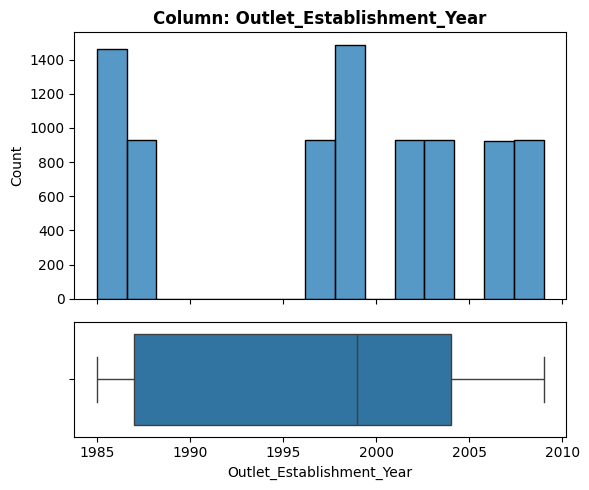

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [42]:
# Run the appropriate explore function (based on feature's dtype)
explore_numeric(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Technically stored as a number (year), but conceptually it behaves more like an **ordinal/discrete** feature - there are only 9 unique establishment years (1985-2009) shared across the 10 outlets.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - values are spread across 9 different years.

4. What is the cardinality? Is it high (>10)?
   - 9 unique values. Cardinality is low (<10).

5. Would we know this feature before the target is determined?
   - Yes, the year a store was established is a fixed, known fact.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. The age of a store (which can be derived from this year) could plausibly relate to its customer base, reputation, and sales patterns.

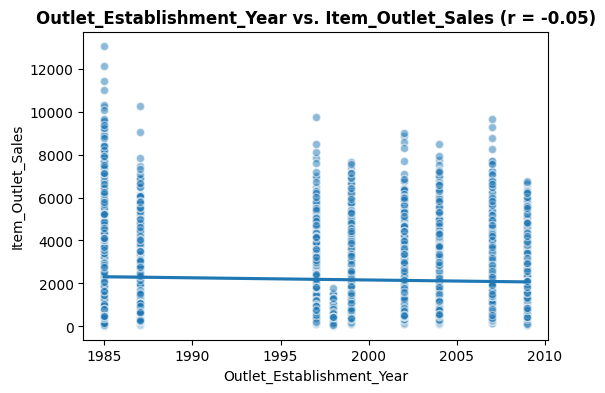

In [43]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Possibly - older, more established stores might have built up a loyal customer base (higher sales), or alternatively newer stores might be in better locations.
  - Does this feature appear to be a predictor of the target?
    - The regplot shows a correlation very close to 0, suggesting `Outlet_Establishment_Year` has little to no linear relationship with `Item_Outlet_Sales` on its own.

### Outlet_Size

- Outlet_Size: The size of the store in terms of ground area covered

In [44]:
# Confirming the dtype to select correct EDA function
feature = "Outlet_Size"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


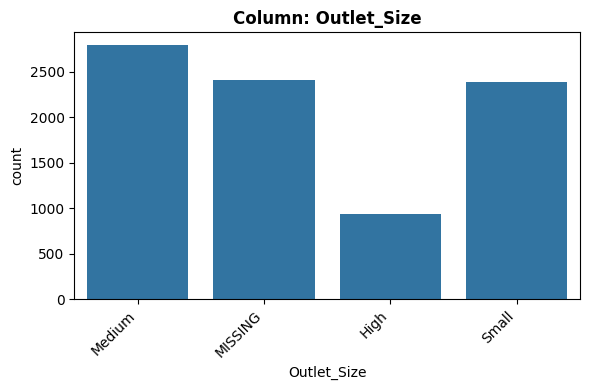

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [45]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Ordinal - `Small` < `Medium` < `High` represents an inherent order of store size.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 2,410 nulls (~28.27%). This is a large percentage, too large to drop the rows. We will **impute** these with a placeholder category (e.g., `'MISSING'`) using `SimpleImputer(strategy='constant', fill_value='MISSING')` in Part 5, so the missingness itself can be treated as its own category and one-hot encoded.

3. Is the feature constant or quasi-constant?
   - No - `Medium` is the most common value, but at roughly 33% of rows it is well below the 98% threshold.

4. What is the cardinality? Is it high (>10)?
   - 3 unique values (`Small`, `Medium`, `High`), or 4 if counting the missing placeholder. Cardinality is low.

5. Would we know this feature before the target is determined?
   - Yes, a store's physical size is a fixed attribute known before any sales occur.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. Store size is a plausible driver of total sales volume (larger stores may stock more products and serve more customers).

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


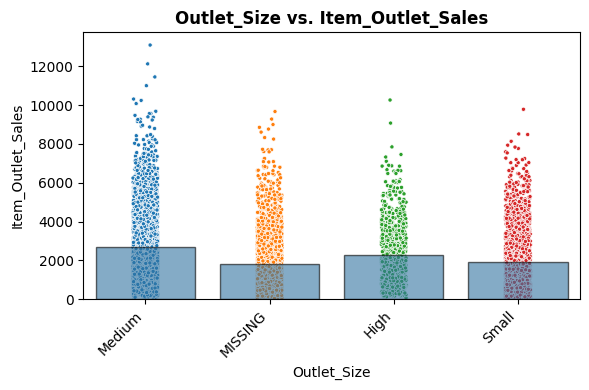

In [46]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - larger stores likely sell more in total/on average than smaller ones.
  - Does this feature appear to be a predictor of the target?
    - Somewhat. The bar plot shows `High` and `Medium` outlets have noticeably higher average `Item_Outlet_Sales` than `Small` outlets and the `MISSING` group. `Outlet_Size` appears to have some predictive value.

### Outlet_Location_Type

- Outlet_Location_Type: The type of area in which the store is located

In [47]:
# Confirming the dtype to select correct EDA function
feature = "Outlet_Location_Type"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


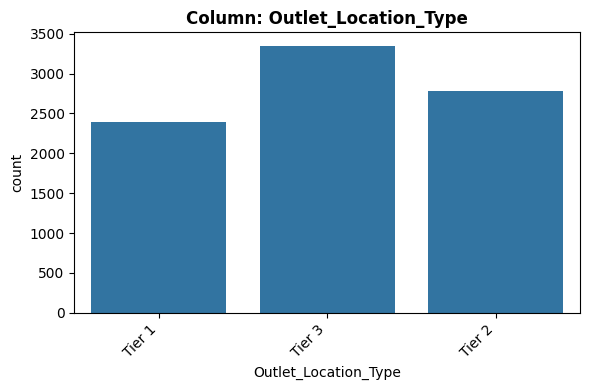

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [48]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Ordinal - `Tier 1`, `Tier 2`, `Tier 3` likely represent an ordered classification of city/area type (though the exact ordering direction would need confirmation from the data source).

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - values are distributed across the 3 tiers without one dominating at >98%.

4. What is the cardinality? Is it high (>10)?
   - 3 unique values. Cardinality is low.

5. Would we know this feature before the target is determined?
   - Yes, the location/tier of a store is a fixed, known attribute.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. The type of area a store is located in (e.g., a major city vs. a smaller town) could plausibly influence customer traffic and sales.

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


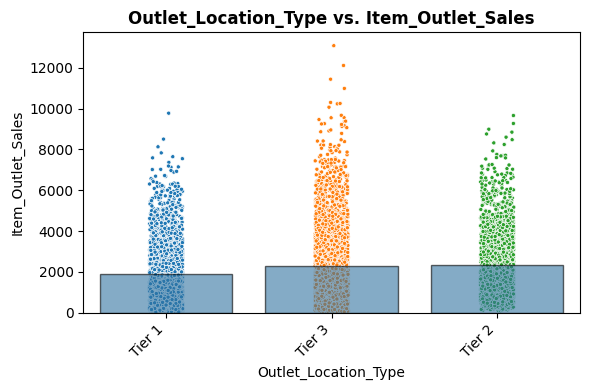

In [49]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - stores in different tiers/areas likely see different levels of customer traffic and spending.
  - Does this feature appear to be a predictor of the target?
    - Somewhat. The bar plot shows `Tier 2` and `Tier 3` have higher average `Item_Outlet_Sales` than `Tier 1`, suggesting some relationship, though the spreads (stripplots) overlap considerably.

### Outlet_Type

- Outlet_Type: Whether the outlet is a grocery store or some sort of supermarket

In [50]:
# Confirming the dtype to select correct EDA function
feature = "Outlet_Type"
df[feature].dtype

dtype('O')

/tmp/ipykernel_5946/506434212.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


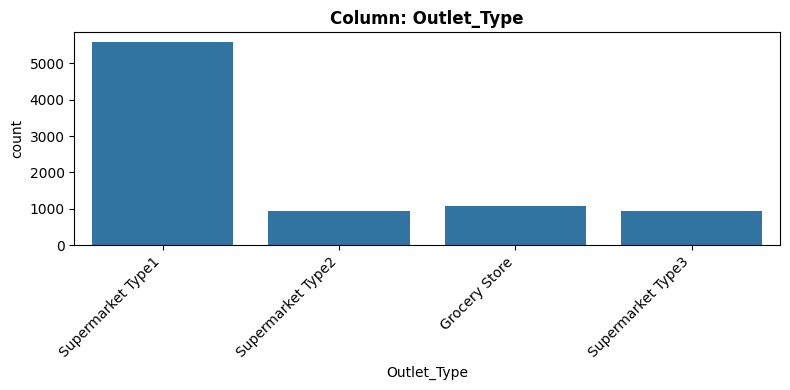

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [51]:
# Run the appropriate explore function (based on feature's dtype)
explore_categorical(df, feature, figsize=(8, 4));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Categorical (nominal) - though there is a loose ordinal sense in which `Grocery Store` < `Supermarket Type1/2/3` in terms of overall store scale.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). No action needed.

3. Is the feature constant or quasi-constant?
   - No - `Supermarket Type1` is the most common (~65%), but below the 98% quasi-constant threshold.

4. What is the cardinality? Is it high (>10)?
   - 4 unique values. Cardinality is low.

5. Would we know this feature before the target is determined?
   - Yes, the type of outlet is a fixed attribute known before any sales occur.

6. Is there a business case/understanding reason to exclude based on our business case?
   - No. This is highly relevant - the type of store (small grocery store vs. large supermarket) is likely to be one of the most important predictors of total sales.

/tmp/ipykernel_5946/3600475188.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


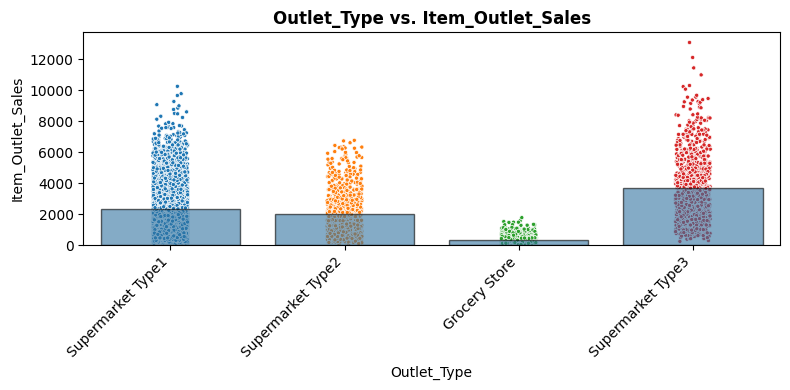

In [52]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df, feature, 'Item_Outlet_Sales', figsize=(8, 4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes - `Grocery Store` outlets likely have much lower per-item sales than full supermarkets.
  - Does this feature appear to be a predictor of the target?
    - Yes, strongly. The bar plot shows `Grocery Store` has dramatically lower average `Item_Outlet_Sales` than all three `Supermarket` types, with `Supermarket Type3` having the highest average. `Outlet_Type` appears to be one of the strongest categorical predictors.

### Item_Outlet_Sales (Target)

- Item_Outlet_Sales: Sales of the product in the particular store. This is the **target variable** to be predicted.

In [53]:
# Confirming the dtype to select correct EDA function
feature = "Item_Outlet_Sales"
df[feature].dtype

dtype('float64')

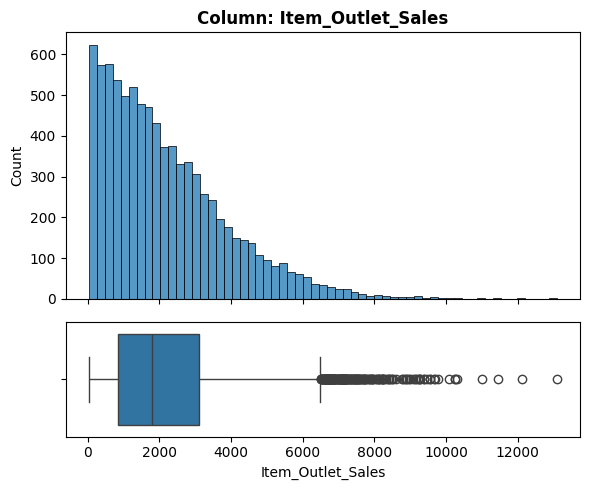

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [54]:
# Run the appropriate explore function (based on feature's dtype)
explore_numeric(df, feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
   - Numeric (continuous). This is our **target variable**.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
   - 0 nulls (0.0%). Since this is the target, if it had nulls we would need to **drop those rows** (we cannot impute a target value - that would be fabricating the answer we're trying to predict). Fortunately, no action is needed here.

3. Is the feature constant or quasi-constant?
   - No - it has a wide, right-skewed spread of values.

4. What is the cardinality? Is it high (>10)?
   - High cardinality (continuous float values), as expected for a regression target.

5. Would we know this feature before the target is determined?
   - N/A - this IS the target.

6. Is there a business case/understanding reason to exclude based on our business case?
   - N/A - this is the value we are trying to predict.

In [55]:
# Run the appropriate feature vs. target function (based on dtype)
# (Skipped here since this IS the target - plotting it against itself
#  would trivially show a perfect r = 1.00 line.)
print("Item_Outlet_Sales is the target variable; skipping feature-vs-target plot.")

Item_Outlet_Sales is the target variable; skipping feature-vs-target plot.


- Feature vs. Target Observations:
  - N/A - this is the target variable itself.